# Figure 4 — Grouped forest plot: method comparison (Bank Marketing, B&W)

Compares the 95\% uplift CIs from three methods (Bootstrap percentile, Analytic Wald, Bayesian) for each Bank Marketing rule. Methods are shown side by side at small vertical offsets and are distinguished by marker *shape* + line *style*.

**Output:** `article/figures/fig4_grouped_forest_comparison.pdf`.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import pandas as pd
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
if str(REPO / 'notebooks' / 'article' / 'figures') not in sys.path:
    sys.path.insert(0, str(REPO / 'notebooks' / 'article' / 'figures'))
from _style import DOUBLE_COL_INCHES, METHOD_STYLE, METHOD_LABEL, apply_rc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
apply_rc()
CSV = REPO / 'article' / 'results' / 'rule_level_cis.csv'
PDF = REPO / 'article' / 'figures' / 'fig4_grouped_forest_comparison.pdf'
df = pd.read_csv(CSV)
df = df[df['dataset'] == 'UCI Bank Marketing'].copy()
methods = ['bootstrap_percentile', 'wald', 'bayesian']
df = df[df['method'].isin(methods)]
print(df['method'].value_counts().to_dict())

{'bootstrap_percentile': 24, 'wald': 24, 'bayesian': 24}


wrote article\figures\fig4_grouped_forest_comparison.pdf


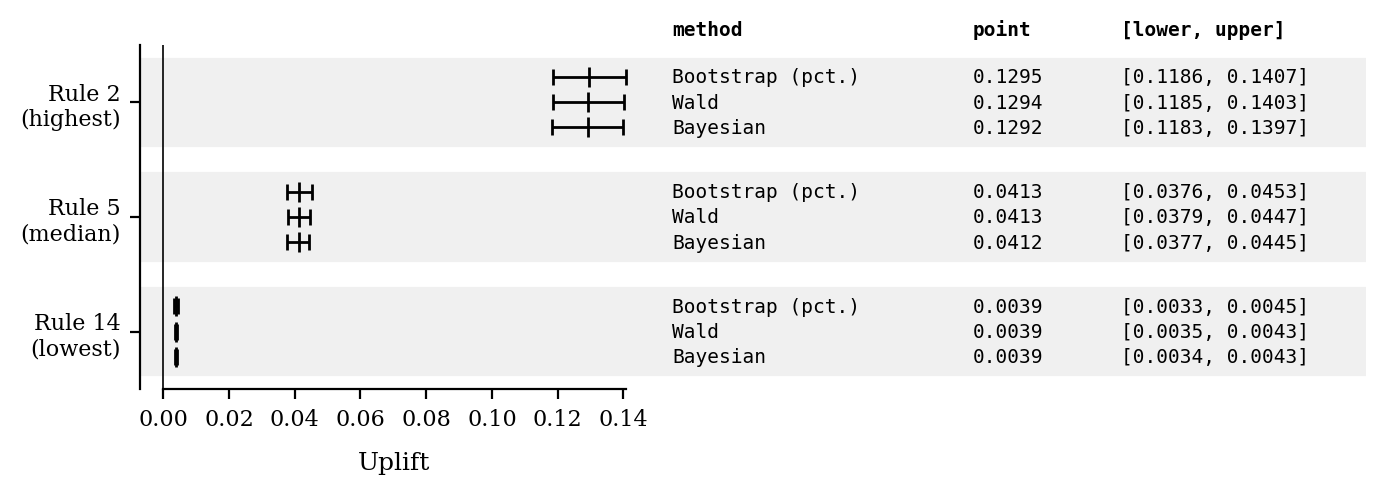

In [2]:
# Select 3 representative rules by uplift point estimate (bootstrap percentile ranking):
# the rule with the lowest, median, and highest uplift.  This replaces the 24-rule
# vertical layout, which made individual point + CI values unreadable while the
# article's claim ("the three methods produce nearly indistinguishable intervals")
# was diluted by visual clutter.
ranking = df[df['method'] == 'bootstrap_percentile'].sort_values('uplift_point').reset_index(drop=True)
n_total = len(ranking)
selected = ranking.iloc[[0, n_total // 2, n_total - 1]]['rule_index'].tolist()
position_label = {selected[0]: 'lowest', selected[1]: 'median', selected[2]: 'highest'}
df_sel = df[df['rule_index'].isin(selected)].copy()

# Layout: y=0 is lowest uplift (bottom), y=2 is highest (top).
y_map = {r: i for i, r in enumerate(selected)}
offsets = {'bootstrap_percentile': 0.22, 'wald': 0.0, 'bayesian': -0.22}

fig, ax = plt.subplots(figsize=(DOUBLE_COL_INCHES, 2.6))

# Light horizontal row guides — one band per rule, behind the markers.
for r in selected:
    ax.axhspan(y_map[r] - 0.38, y_map[r] + 0.38, color='0.94', zorder=0)

xmax = df_sel['uplift_ci_upper'].max()

# All three methods share the same line+cap style; methods are distinguished
# only by their row label in the numeric table on the right.
for method in methods:
    sub = df_sel[df_sel['method'] == method]
    for _, row in sub.iterrows():
        y = y_map[row['rule_index']] + offsets[method]
        x = row['uplift_point']
        ax.errorbar(
            x, y,
            xerr=[[max(x - row['uplift_ci_lower'], 0)],
                  [max(row['uplift_ci_upper'] - x, 0)]],
            fmt='|', color='black', ecolor='black', capsize=3,
            markersize=7, markeredgewidth=1.0, linewidth=1.0, zorder=3,
        )

# Numeric table on the right.  Each row carries its method name, point estimate,
# and CI bracket in three monospace columns sized to avoid overlap.
method_col_x = xmax * 1.10
point_col_x = xmax * 1.75
ci_col_x = xmax * 2.07
for method in methods:
    sub = df_sel[df_sel['method'] == method]
    label = METHOD_LABEL[method]
    for _, row in sub.iterrows():
        y = y_map[row['rule_index']] + offsets[method]
        ax.text(method_col_x, y, label, va='center', ha='left',
                fontsize=7, family='monospace', zorder=4)
        ax.text(point_col_x, y, f"{row['uplift_point']:.4f}", va='center', ha='left',
                fontsize=7, family='monospace', zorder=4)
        ax.text(ci_col_x, y,
                f"[{row['uplift_ci_lower']:.4f}, {row['uplift_ci_upper']:.4f}]",
                va='center', ha='left', fontsize=7, family='monospace', zorder=4)

# Column headers for the numeric table.
header_y = len(selected) - 0.5 + 0.05
for x_pos, label in [(method_col_x, 'method'), (point_col_x, 'point'),
                     (ci_col_x, '[lower, upper]')]:
    ax.text(x_pos, header_y, label, va='bottom', ha='left',
            fontsize=7, family='monospace', fontweight='bold', zorder=4)

ax.set_yticks(range(len(selected)))
ax.set_yticklabels([f'Rule {r}\n({position_label[r]})' for r in selected])
ax.axvline(0, color='black', linewidth=0.6, zorder=1)
ax.set_ylim(-0.5, 2.5)

# Restrict the x-axis spine and tick range to the data region (no spine under the
# numeric-annotation column), but leave xlim wide so the text has room.
ax.spines['bottom'].set_bounds(0, xmax)
ax.set_xticks([t for t in ax.get_xticks() if 0 <= t <= xmax + 1e-9])
xlim_left = -xmax * 0.05
xlim_right = xmax * 2.60
ax.set_xlim(xlim_left, xlim_right)

# Center the 'Uplift' x-label over the data portion of the axis (0..xmax) rather
# than over the wide xlim that includes the numeric-annotation column.
data_mid_axes_frac = (0.5 * xmax - xlim_left) / (xlim_right - xlim_left)
ax.set_xlabel('Uplift')
ax.xaxis.set_label_coords(data_mid_axes_frac, -0.18)

fig.tight_layout()
fig.savefig(PDF, format='pdf', bbox_inches='tight')
print('wrote', PDF.relative_to(REPO))
plt.show()